In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
num_pnts = 15
runs = 10
infection_model = 'acute'
sample_virs = np.array(np.meshgrid(d_S*np.linspace(10, 200, num_pnts), # vary d_I
                                   K_IE*np.logspace(0.0, 3, num_pnts), # vary K_IE
                                   b_I*np.linspace(0.1, 2.0, num_pnts), # vary b_I
                                   K_EH*np.array([1.0]), # vary K_EH
                                   N_0*np.array([1.0]), # vary N_0
                                   I_0*np.array([1.0]) # vary I_0
                                       )).T.reshape(-1,6)

act_psis = [psi_max, psi_max, psi_max, -1/2*L0_max]
NE_psis = [psi_max, psi_max, psi_max, L0_max] # regulatory weights: psi_M_I, psi_M_H, psi_M_P
EM_psis = [-psi_max, -psi_max, -0*psi_max, -L0_max]
exp_psis = [psi_max, psi_max, psi_max, L0_max]
default_reg = act_psis + NE_psis + EM_psis + exp_psis


d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
# d="_local_data/"

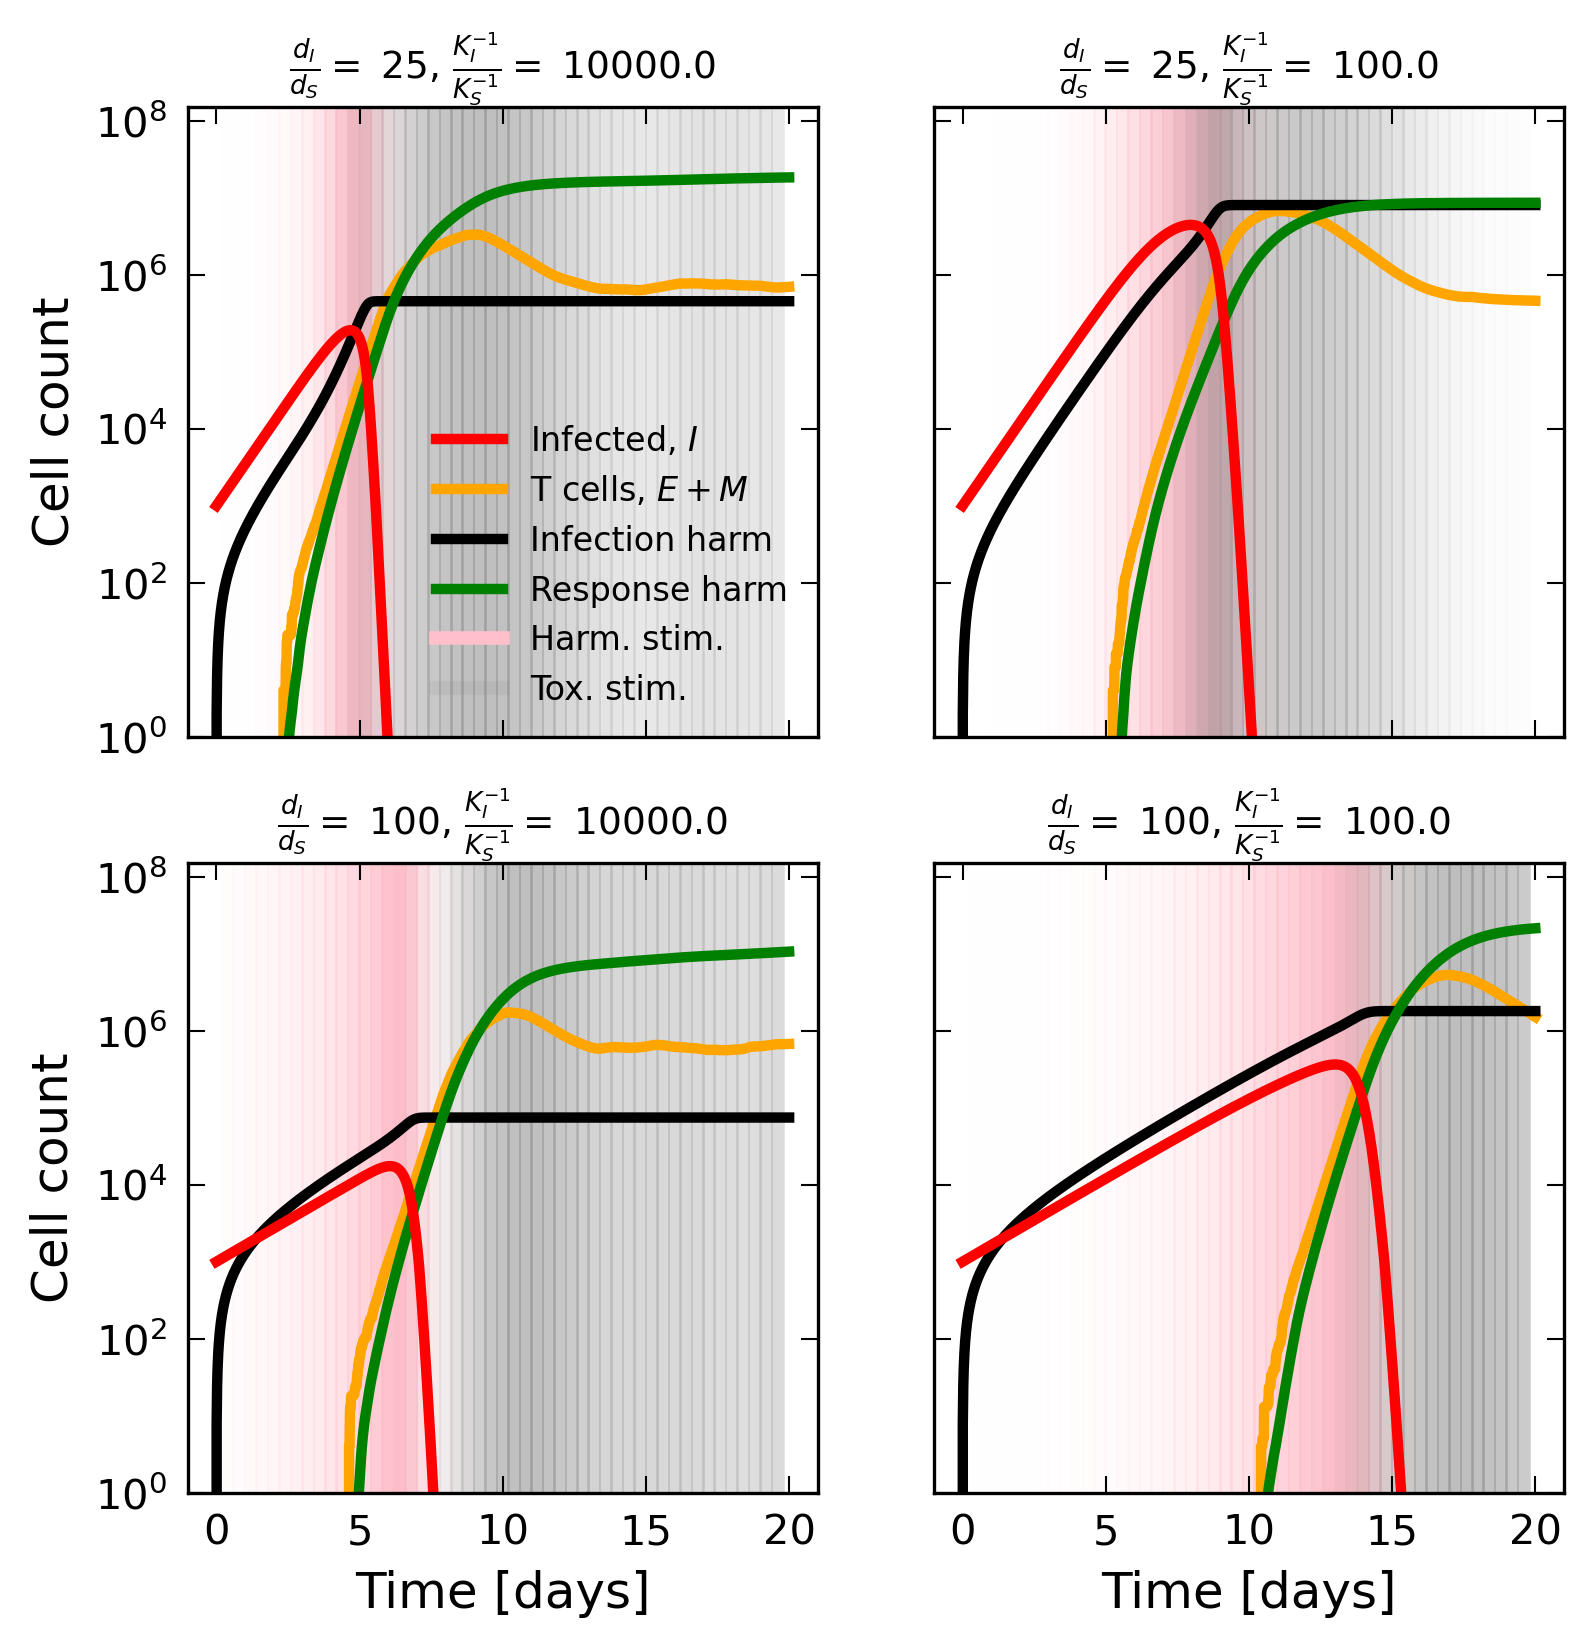

In [17]:
# Plot select infection responses
fig, axs = plt.subplots(2,2, dpi = 150, sharex = True, sharey = True, figsize=(6,6))

scenarios = np.array(np.meshgrid(d_S*np.linspace(25, 100, 2), # vary d_I
                                   K_IE*np.logspace(0.0, 2, 2), # vary K_IE
                                   b_I*np.array([1.5]), # vary b_I
                                   K_EH*np.logspace(0.0, 0.0, 1), # vary K_EH
                                   N_0*np.logspace(0.0, 0.0, 1), # vary N_0
                                   I_0*np.logspace(0.0, 0.0, 1) # vary I_0
                                           )).T.reshape(-1,6)
# Loop and do 
for k, ax in enumerate(axs.flat):

    # Run single simulation
    data_dict = lin_stoch_sim(N_0 = scenarios[k,4],
                              I_0 = scenarios[k,5],
                              b_I = scenarios[k,2], 
                              K_IE = scenarios[k,1],
                              d_I = scenarios[k,0],
                              K_EH = scenarios[k,3],
                              NE_regulation = NE_psis,
                              EM_regulation = EM_psis,
                              activation_regulation = act_psis,
                              expansion_regulation = exp_psis,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    regs = data_dict["reg_coeffs"]
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    lin_comp = data_dict["lineage_diff"]
    p_diff = data_dict["prim_diff_bias"]
    parameters = data_dict["parameters"]
    sim_summary = data_dict["summary_stats"]
    mycN = data_dict["N_myc_by_lin"]
    mycMa = data_dict["Ma_myc_by_lin"]
    mycE = data_dict["E_myc_by_lin"]
    Eff = data_dict["eff_by_lin"]
    T_pEcytM = data_dict["pmemory_formed"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]
    
    # Plot simulated infection dynamics: pretty plots
    pnts = 50
    keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
    sus = S[keep]
    naive = Na[keep]
    eff = E[keep]
    mem = M[keep]
    p_load = np.log(1 + I[keep]/K_IE)/np.log(1 + np.max(I[keep])/K_IE) if np.max(I[keep]) > 0 else I[keep]
    inflam = np.log((1 + HI[keep]/K_EH))/np.log((1 + np.max(HI[keep])/K_EH))
    anti_inflam = np.log((1 + HE[keep]/K_EH))/np.log((1 + np.max(HE[keep])/K_EH)) if np.max(HE[keep]) > 0 else HE[keep]
    inf_harm = I_d_I[keep]
    toxicity = I_d_S[keep]
    time = ts[keep]
    
    ax.plot(ts, I, 'r', label = r'Infected, $I$', linewidth=2.5)
    
    ax.plot(ts, E + M, 'orange', zorder = 1, linewidth=2.5, label = r'T cells, $E + M$')
    # im = ax.scatter(time, eff+mem, marker ='o', c = p_load, cmap='Purples') #, norm=mpl.colors.LogNorm())
    
    ax.plot(ts, I_d_I, 'black', zorder = 1, linewidth=2.5, label = r'Infection harm')
    ax.plot(ts, I_d_S, 'green', zorder = 1, linewidth=2.5, label = r'Response harm')

    ax.set_title(r"$\frac{d_I}{d_S} =$ "+str(int(scenarios[k,0]/d_S))+r", $\frac{K_{I}^{-1}}{K_{S}^{-1}} =$ "+str(np.round(K_SE/scenarios[k,1],0)), fontsize = 9.0)
    ax.set_box_aspect(1)
    ax.semilogy()
    ax.minorticks_off()
    ax.set_ylim(1,)
    # locmaj = mpl.ticker.LogLocator(numticks=4)
    # ax.yaxis.set_major_locator(locmaj)
    
    for i in np.arange(0, len(inflam), 1):
        if i == np.argmax(inflam):
            ax.axvline(x=time[i], linestyle='-', linewidth=3.25, color='pink', alpha=inflam[i], label =r"Harm. stim.", zorder = 0)
            ax.axvline(x=time[i], linestyle='-', linewidth=3.25, color='grey', alpha=anti_inflam[i]/2, label =r"Tox. stim.", zorder = 0)
        else:
            ax.axvline(x=time[i], linestyle='-', linewidth=3.25, color='pink', alpha=inflam[i], zorder = 0)
            ax.axvline(x=time[i], linestyle='-', linewidth=3.25, color='grey', alpha=anti_inflam[i]/2, zorder = 0)

# cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
# fig.colorbar(im, cax=cbar_ax)

for k, ax in enumerate(axs.flat):
    if k == 0:
        ax.legend(loc='lower right', fontsize = 8)
    if k % 2  == 0:
        ax.set_ylabel('Cell count', fontsize = 12)
    if k > 1:
        ax.set_xlabel(r"Time [days]", fontsize = 12)
fig.subplots_adjust(wspace=.15, hspace=0.20)

plt.savefig('_figs/'+infection_model+'-scenarios-of-infection-dynamics.png', dpi=150, bbox_inches="tight")

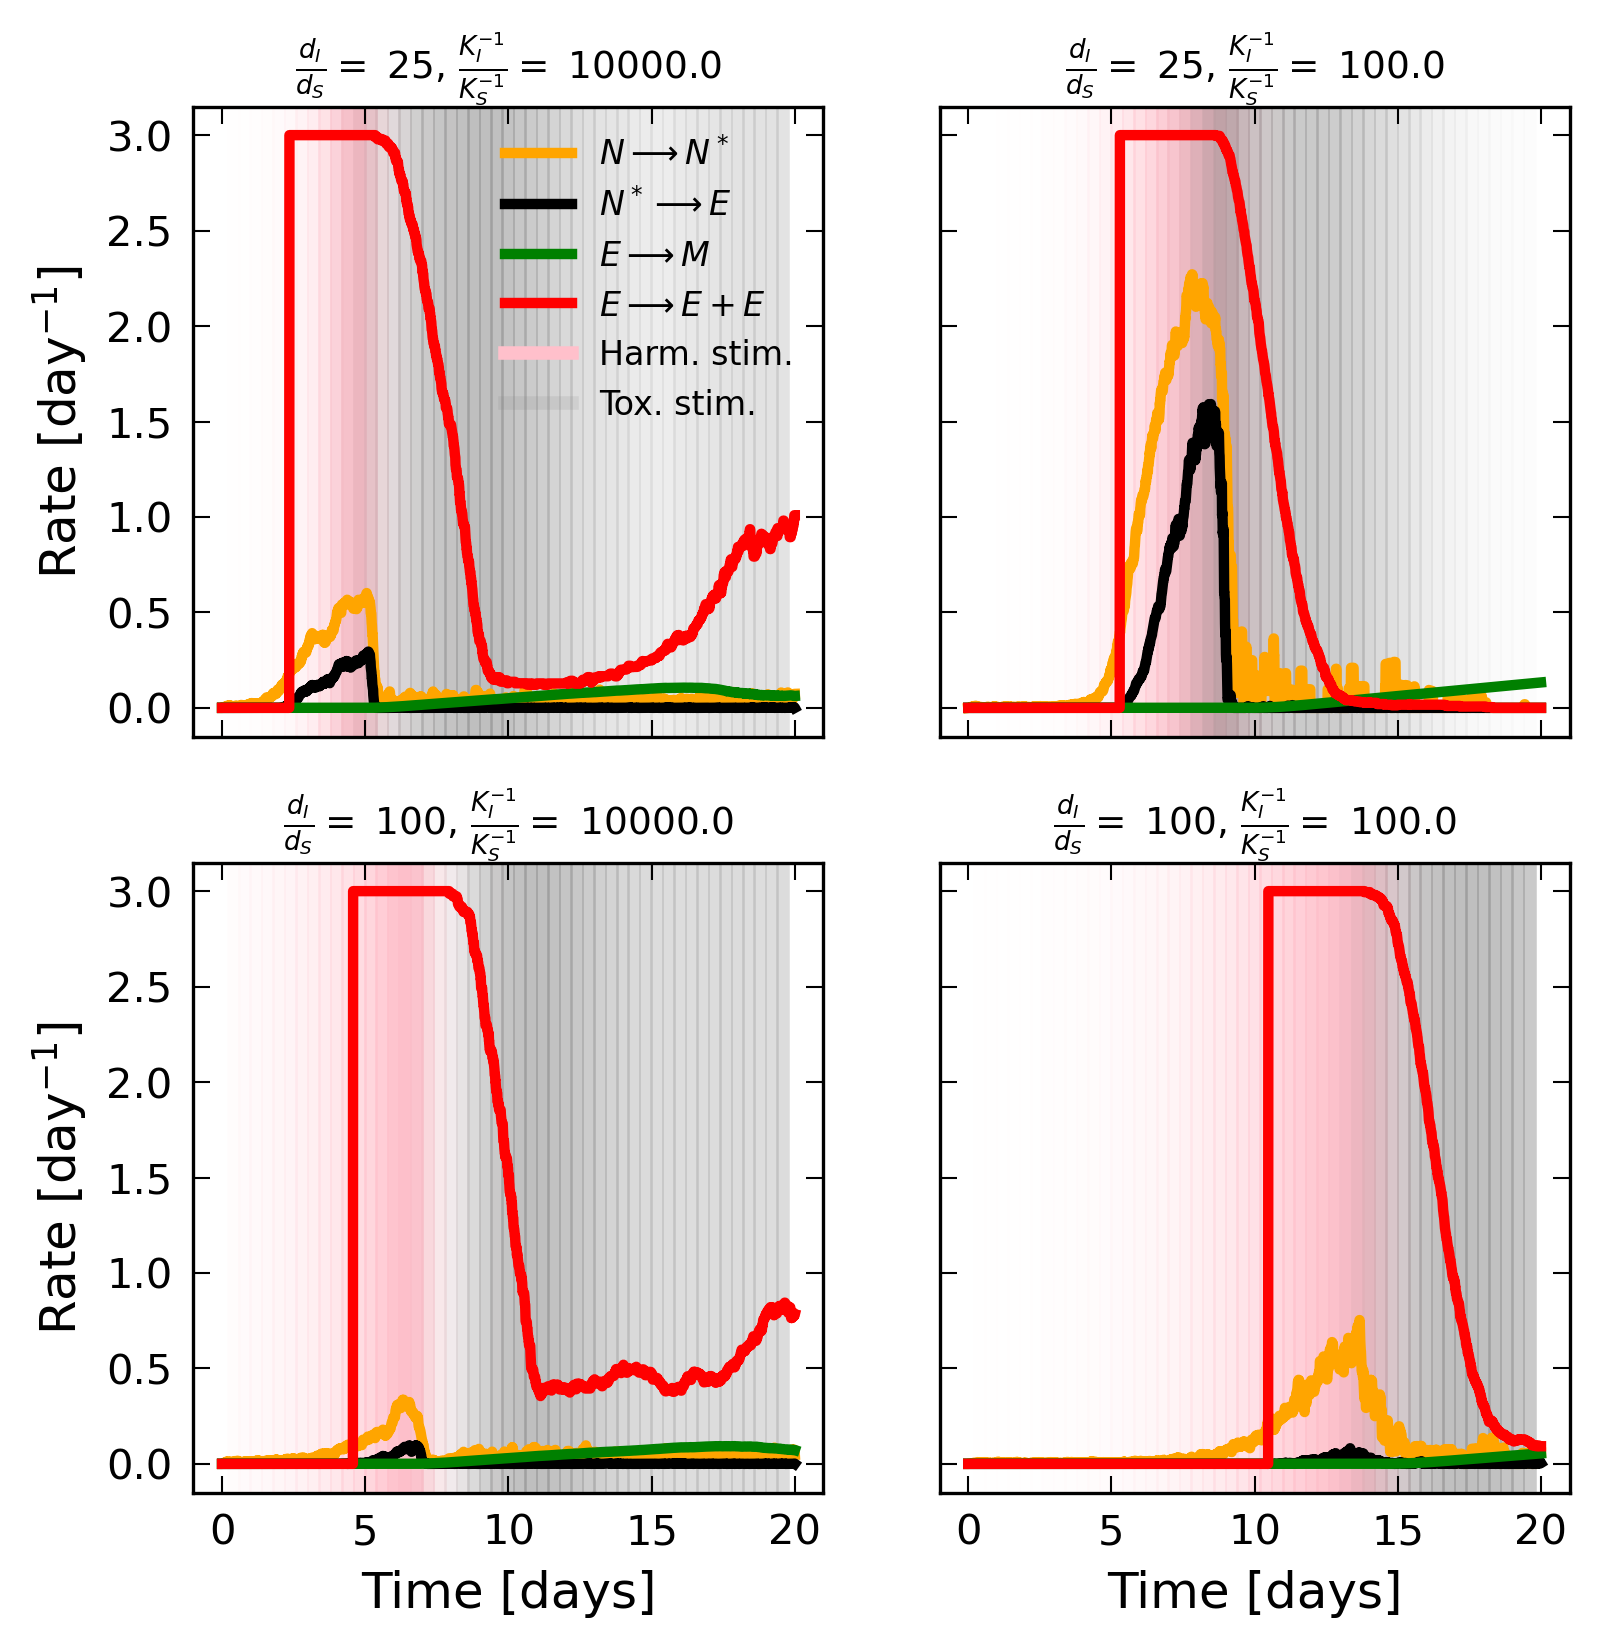

In [18]:
# Plot select infection responses
fig, axs = plt.subplots(2,2, dpi = 150, sharex = True, sharey = True, figsize=(6,6))

scenarios = np.array(np.meshgrid(d_S*np.linspace(25, 100, 2), # vary d_I
                                   K_IE*np.logspace(0.0, 2, 2), # vary K_IE
                                   b_I*np.array([1.5]), # vary b_I
                                   K_EH*np.logspace(0.0, 0.0, 1), # vary K_EH
                                   N_0*np.logspace(0.0, 0.0, 1), # vary N_0
                                   I_0*np.logspace(0.0, 0.0, 1) # vary I_0
                                           )).T.reshape(-1,6)
# Loop and do 
for k, ax in enumerate(axs.flat):

    # Run single simulation
    data_dict = lin_stoch_sim(N_0 = scenarios[k,4],
                              I_0 = scenarios[k,5],
                              b_I = scenarios[k,2], 
                              K_IE = scenarios[k,1],
                              d_I = scenarios[k,0],
                              K_EH = scenarios[k,3],
                              NE_regulation = NE_psis,
                              EM_regulation = EM_psis,
                              activation_regulation = act_psis,
                              expansion_regulation = exp_psis,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    regs = data_dict["reg_coeffs"]
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    lin_comp = data_dict["lineage_diff"]
    p_diff = data_dict["prim_diff_bias"]
    parameters = data_dict["parameters"]
    sim_summary = data_dict["summary_stats"]
    mycN = data_dict["N_myc_by_lin"]
    mycMa = data_dict["Ma_myc_by_lin"]
    mycE = data_dict["E_myc_by_lin"]
    Eff = data_dict["eff_by_lin"]
    T_pEcytM = data_dict["pmemory_formed"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]
    
    # Plot simulated infection dynamics: pretty plots
    pnts = 50
    keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
    sus = S[keep]
    naive = Na[keep]
    eff = E[keep]
    mem = M[keep]
    bias_diff = p_diff
    p_load = np.log(1 + I[keep]/K_IE)/np.log(1 + np.max(I[keep])/K_IE) if np.max(I[keep]) > 0 else I[keep]
    inflam = np.log((1 + HI[keep]/K_EH))/np.log((1 + np.max(HI[keep])/K_EH))
    anti_inflam = np.log((1 + HE[keep]/K_EH))/np.log((1 + np.max(HE[keep])/K_EH)) if np.max(HE[keep]) > 0 else HE[keep]
    inf_harm = I_d_I[keep]
    toxicity = I_d_S[keep]
    time = ts[keep]
    
    ax.plot(ts, bias_diff[:,0], 'orange', zorder = 1, linewidth=2.5, label = r'$N \longrightarrow N^*$')
    ax.plot(ts, bias_diff[:,1], 'black', zorder = 1, linewidth=2.5,label = r'$N^* \longrightarrow E$')
    ax.plot(ts, bias_diff[:,2], 'green', zorder = 1, linewidth=2.5, label = r'$E \longrightarrow M$')
    ax.plot(ts, bias_diff[:,3], 'red', zorder = 1, linewidth=2.5, label = r'$E \longrightarrow E + E$')

    ax.set_title(r"$\frac{d_I}{d_S} =$ "+str(int(scenarios[k,0]/d_S))+r", $\frac{K_{I}^{-1}}{K_{S}^{-1}} =$ "+str(np.round(K_SE/scenarios[k,1],0)), fontsize = 9.0)
    ax.set_box_aspect(1)
    # cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink = 0.65, pad = 0.05)
    # cb.set_label('Ag. stimulation', fontsize = 12)
    ax.minorticks_off()
    #ax.semilogy()
    # locmaj = mpl.ticker.LogLocator(numticks=4)
    # ax.yaxis.set_major_locator(locmaj)
    
    for i in np.arange(0, len(inflam), 1):
        if i == np.argmax(inflam):
            ax.axvline(x=time[i], linestyle='-', linewidth=3.25, color='pink', alpha=inflam[i], label =r"Harm. stim.", zorder = 0)
            ax.axvline(x=time[i], linestyle='-', linewidth=3.25, color='grey', alpha=anti_inflam[i]/2, label =r"Tox. stim.", zorder = 0)
        else:
            ax.axvline(x=time[i], linestyle='-', linewidth=3.25, color='pink', alpha=inflam[i], zorder = 0)
            ax.axvline(x=time[i], linestyle='-', linewidth=3.25, color='grey', alpha=anti_inflam[i]/2, zorder = 0)

# cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
# fig.colorbar(im, cax=cbar_ax)

for k, ax in enumerate(axs.flat):
    if k == 0:
        ax.legend(loc='upper right', fontsize = 8)
    if k % 2  == 0:
        ax.set_ylabel('Rate [day$^{-1}$]', fontsize = 12)
    if k > 1:
        ax.set_xlabel(r"Time [days]", fontsize = 12)
fig.subplots_adjust(wspace=.15, hspace=0.20)

plt.savefig('_figs/'+infection_model+'-scenarios-of-infection-regulation.png', dpi=150, bbox_inches="tight")

In [5]:
# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample_virs, 
    comment="single-reg-vary-virs", runs = runs, infection_model = infection_model, default_reg = default_reg, 
    num_cpu = 120)

Running 33750 simulations in batch #-1
Saved sim_batch_-1-10-acute-single-reg-vary-virs.pkl
0.09438826402028401 hrs


In [6]:
d_file = d + '/sim_batch_-1-'+str(runs)+'-'+infection_model+'-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]

In [7]:
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
sim_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).dropna(thresh=1)
use_data = sim_df.loc[sim_df['b_I']*sim_df['S_0'] >= sim_df['d_I']]

with pd.option_context('display.max_columns', None):
    display(use_data)

,S_0,I_0,b_I,d_S,d_I,d_IE,K_IE,b_H,d_H,K_EH,N_0,max_Na,b_myc,d_myc,myc_thresh,t_bind,t_unbind,t_Na_div,t_E_div,t_M_div,t_E_die,t_act,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,p_load,T_max_pI,T_min_pI,harm_pI,harm_pS,max_pE,T_pE_max,T_pE_start,max_eM,T_eM_min,max_cM,T_cM_min,int_pHE,int_pHI,min_pS
0,10000000.0,1000.0,1.000000e-08,0.01,0.1,16.0,1.000000e+04,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,8662.647312,0.0,0.016,1001.600000,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,429.570911,9.999998e+06
1,10000000.0,1000.0,1.000000e-08,0.01,0.1,16.0,1.637894e+04,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,8662.647312,0.0,0.016,1001.600000,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,429.570911,9.999998e+06
2,10000000.0,1000.0,1.000000e-08,0.01,0.1,16.0,2.682696e+04,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,8662.647312,0.0,0.016,1001.600000,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,429.570911,9.999998e+06
3,10000000.0,1000.0,1.000000e-08,0.01,0.1,16.0,4.393971e+04,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,8662.647312,0.0,0.016,1001.600000,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,429.570911,9.999998e+06
4,10000000.0,1000.0,1.000000e-08,0.01,0.1,16.0,7.196857e+04,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,8662.647312,0.0,0.016,1001.600000,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,429.570911,9.999998e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33745,10000000.0,1000.0,2.000000e-07,0.01,2.0,16.0,1.389495e+06,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,515.999987,0.0,0.016,1031.999974,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,515.999987,9.999968e+06
33746,10000000.0,1000.0,2.000000e-07,0.01,2.0,16.0,2.275846e+06,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,515.999987,0.0,0.016,1031.999974,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,515.999987,9.999968e+06
33747,10000000.0,1000.0,2.000000e-07,0.01,2.0,16.0,3.727594e+06,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,515.999987,0.0,0.016,1031.999974,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,515.999987,9.999968e+06
33748,10000000.0,1000.0,2.000000e-07,0.01,2.0,16.0,6.105402e+06,1.0,2.0,50000.0,1000.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,3.0,-2.302585,3.0,3.0,3.0,4.60517,-3.0,-3.0,0.0,-4.60517,3.0,3.0,3.0,4.60517,515.999987,0.0,0.016,1031.999974,0.0,2000.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,515.999987,9.999968e+06


### Understand noise structure of the simulations

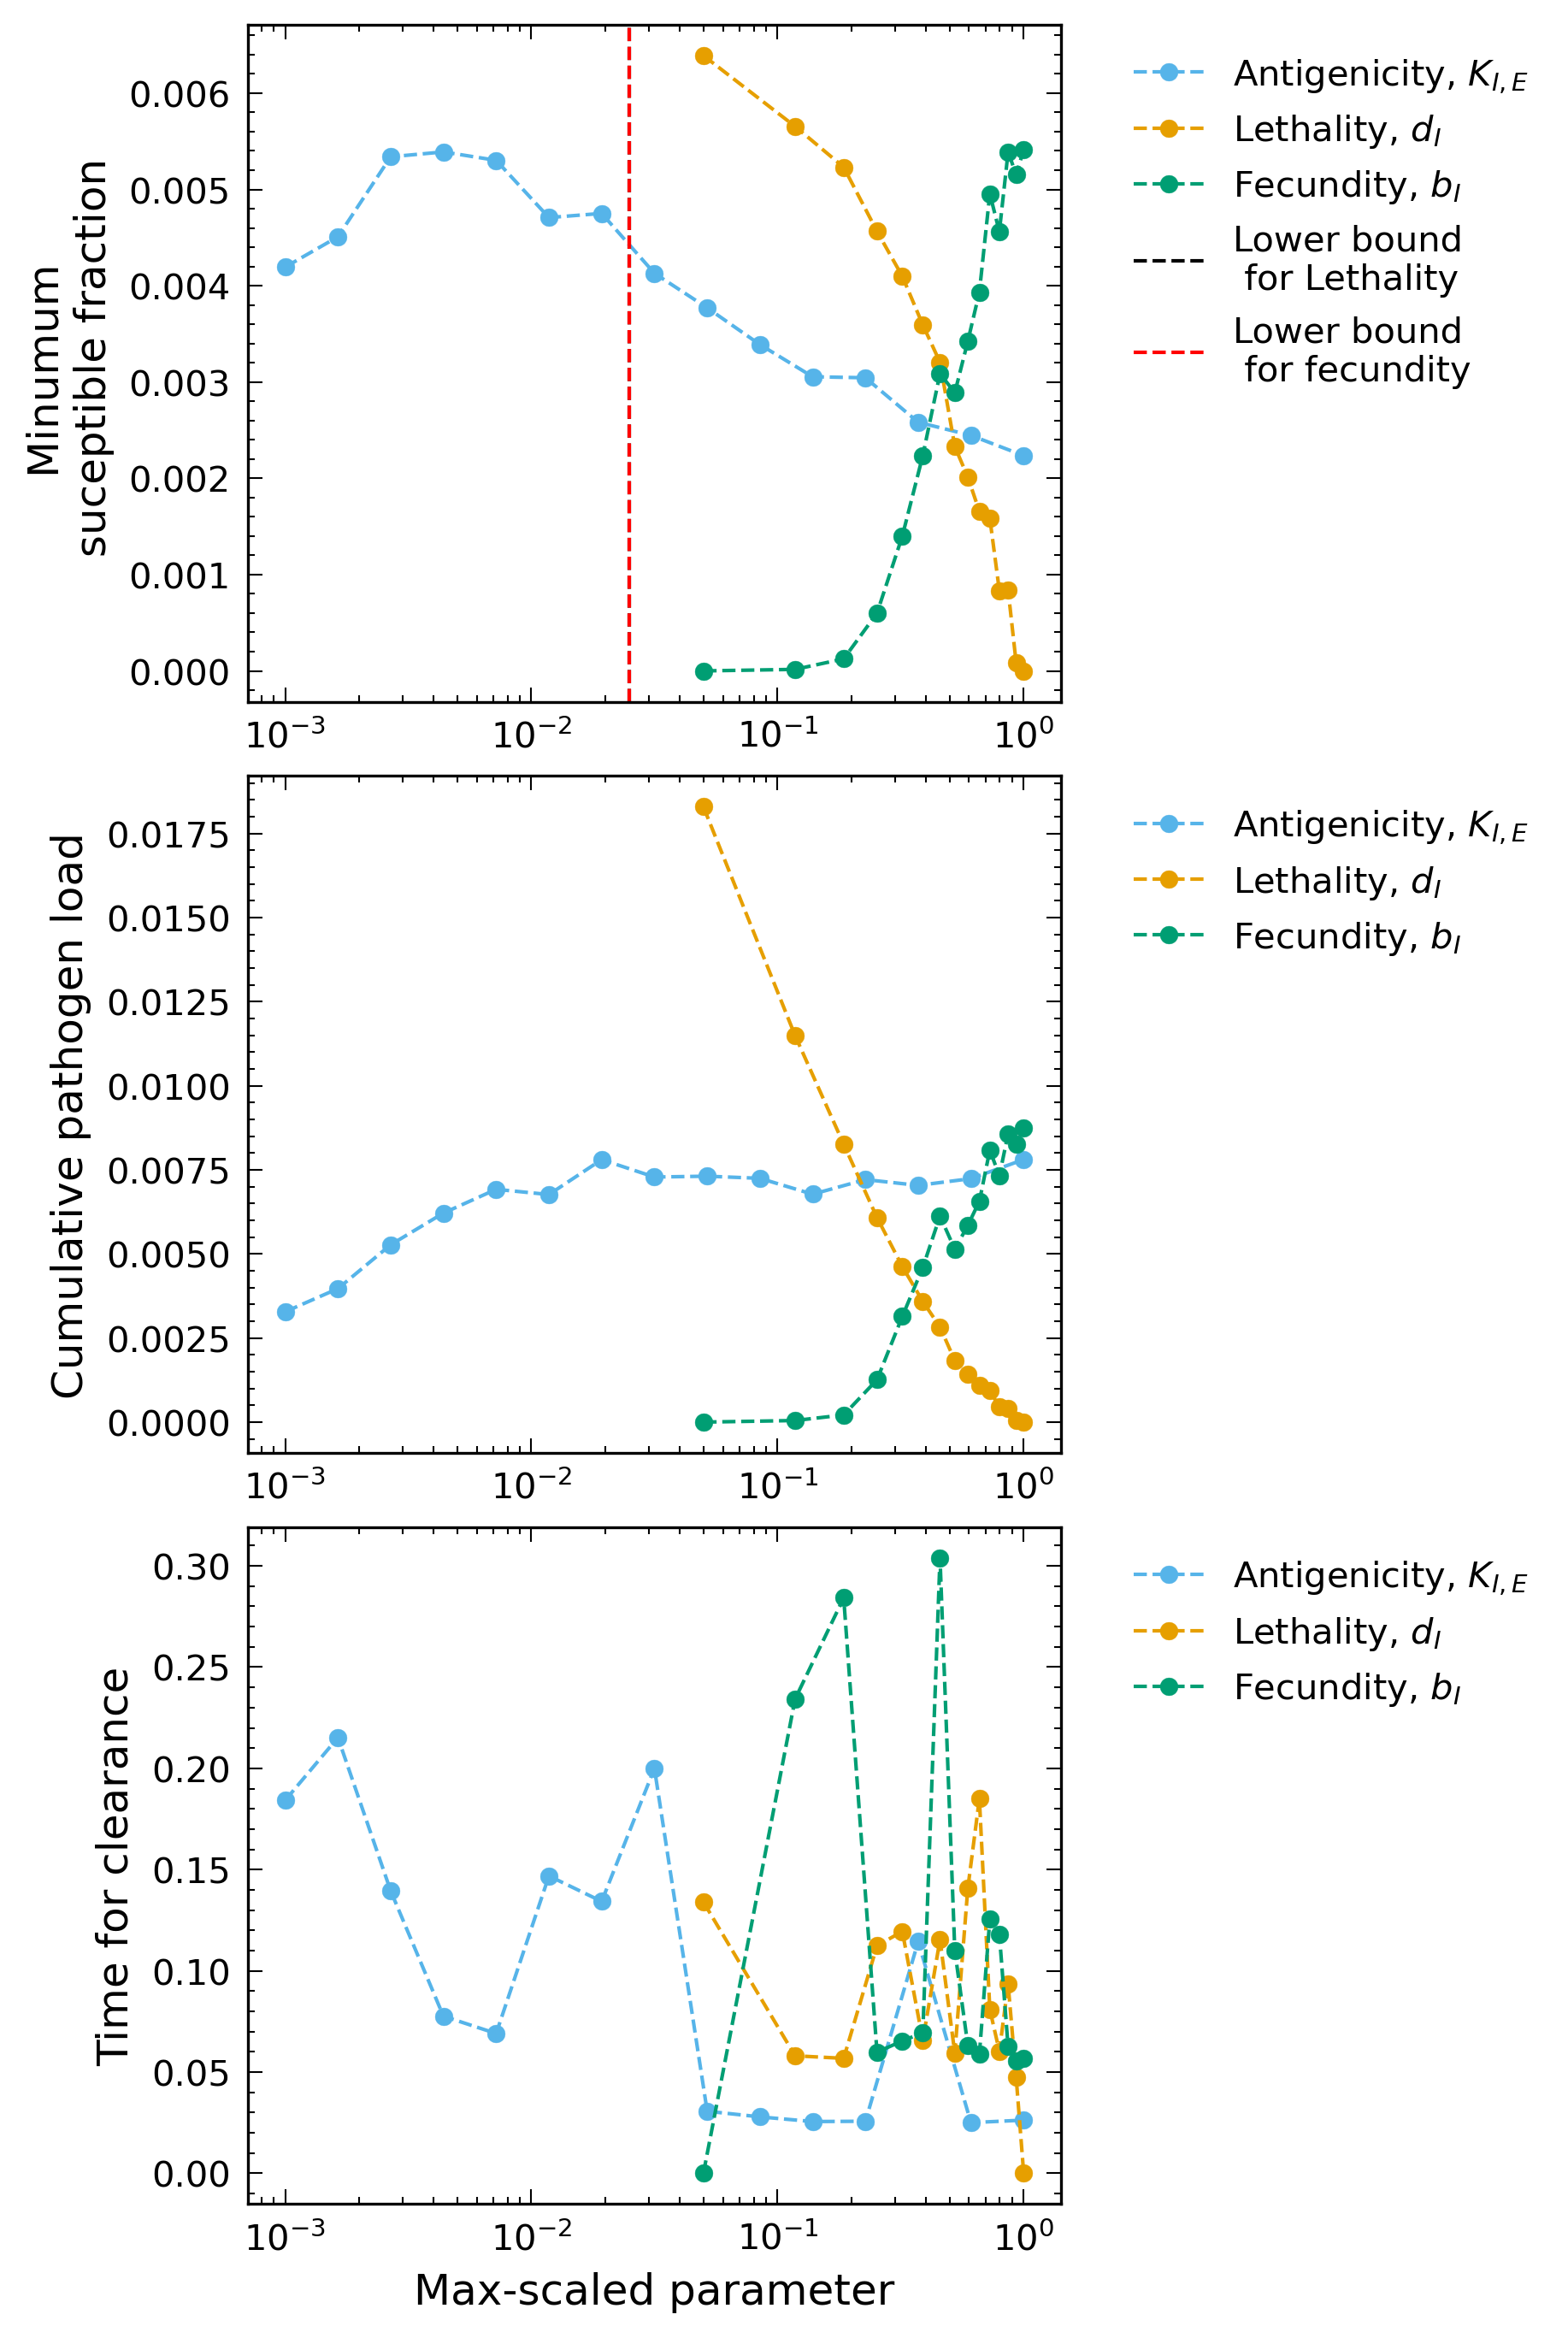

In [8]:
if runs > 1:
    # Plot simulated immune dynamics
    fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))
    
    ax1.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Lethality, $d_{I}$')
    ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
    ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
    ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
    ax1.semilogx()
    ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    ax1.set(ylabel = 'Minumum \n suceptible fraction')
    
    ax2.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Lethality, $d_{I}$')
    ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
    ax2.semilogx()
    ax2.set(ylabel = 'Cumulative pathogen load')
    ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    ax3.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Lethality, $d_{I}$')
    ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Fecundity, $b_{I}$')
    ax3.set(ylabel = 'Time for clearance', xlabel = 'Max-scaled parameter')
    ax3.semilogx()
    ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    
    plt.savefig('_figs/vir_parameter_lineplots_noise', dpi=300, bbox_inches='tight')

### Understand Performance distrubution of the simulations

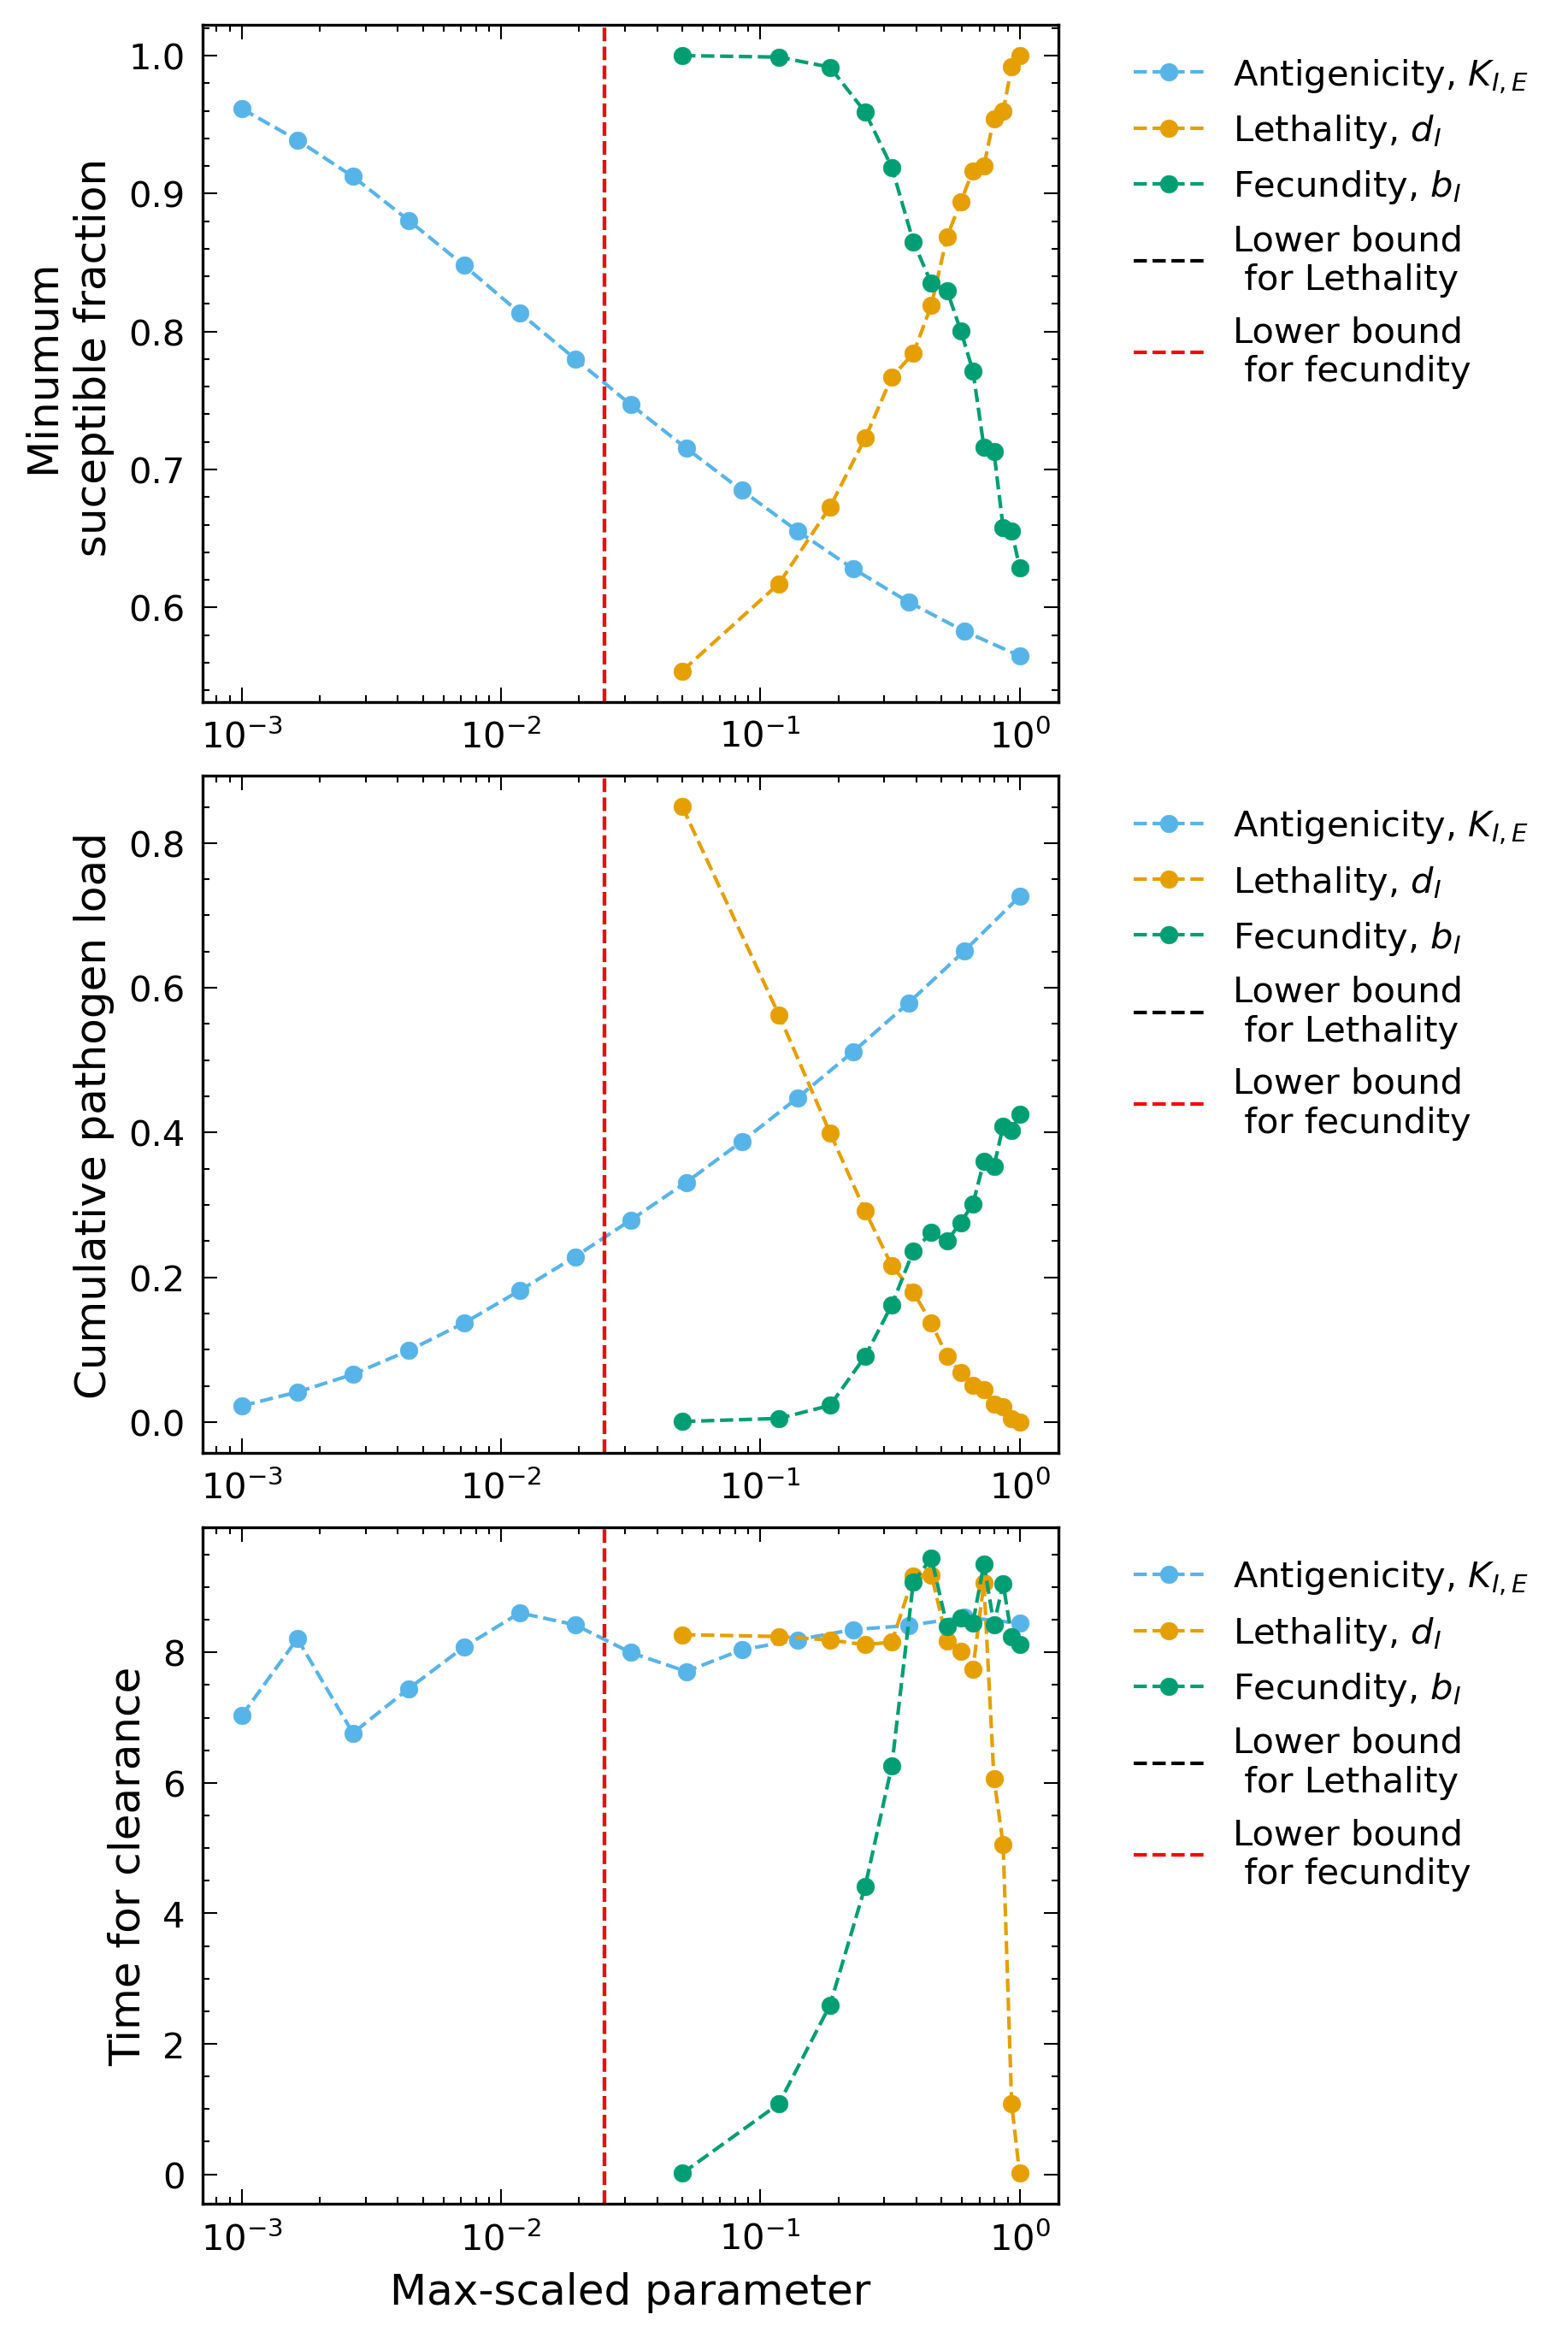

In [9]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))

ax1.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Lethality, $d_{I}$')
ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax1.semilogx()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax1.set(ylabel = 'Minumum \n suceptible fraction')

ax2.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Lethality, $d_{I}$')
ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax2.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax2.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax2.semilogx()
ax2.set(ylabel = 'Cumulative pathogen load')
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Antigenicity, $K_{I,E}$')
ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Lethality, $d_{I}$')
ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Fecundity, $b_{I}$')
ax3.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax3.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax3.set(ylabel = 'Time for clearance', xlabel = 'Max-scaled parameter')
ax3.semilogx()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')


plt.savefig('_figs/vir_parameter_lineplots', dpi=300, bbox_inches='tight')

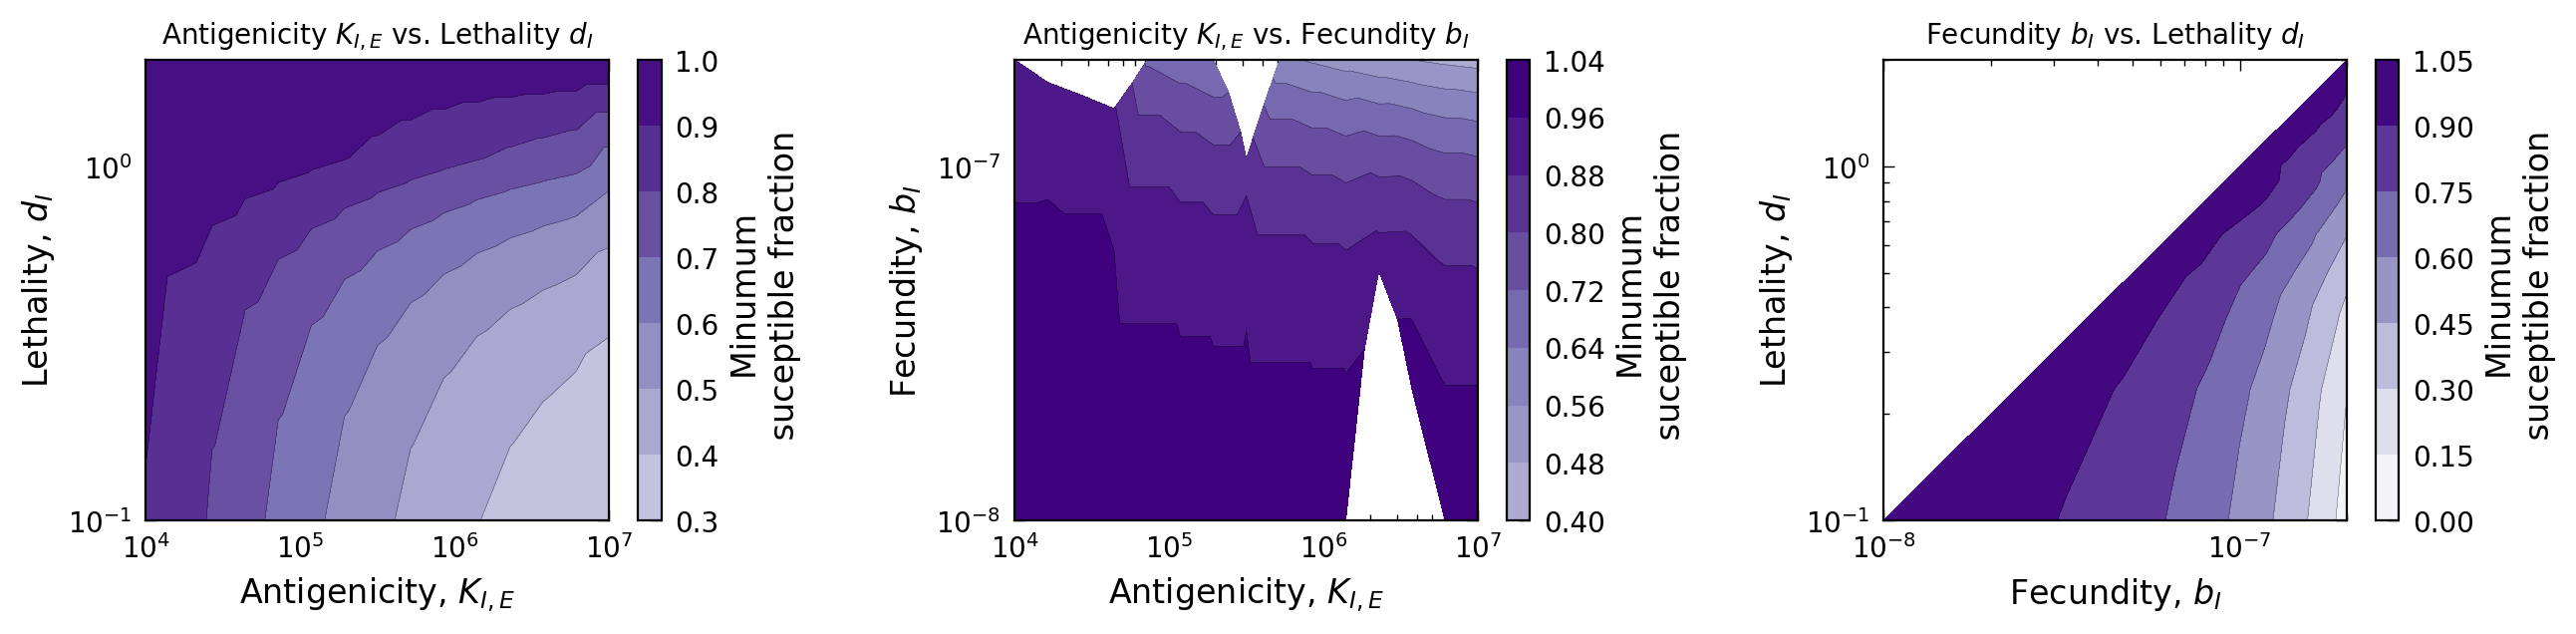

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                  use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im0 = axs[0].tricontourf(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                        use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="Purples", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[1].tricontour(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                  use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im1 = axs[1].tricontourf(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                        use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, cmap="Purples", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[2].tricontour(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im2 = axs[2].tricontourf(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="Purples",norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Fecundity $b_I$ vs. Lethality $d_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 12)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_contour', dpi=300, bbox_inches='tight')

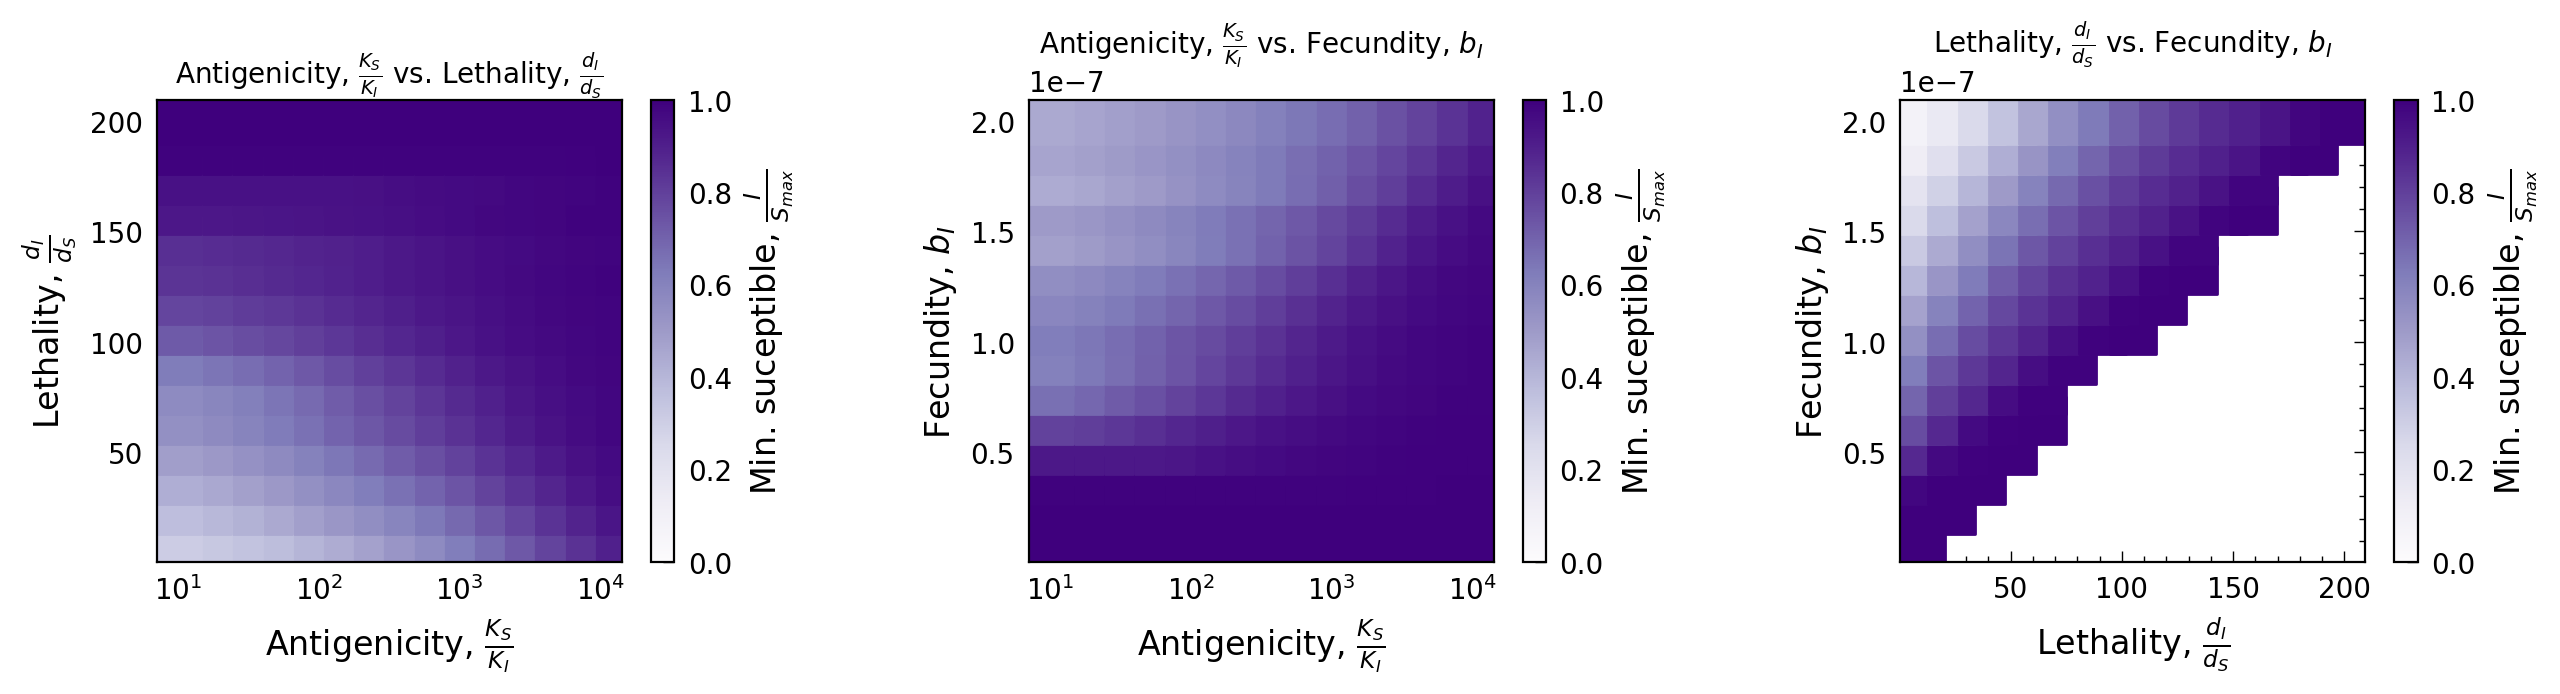

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

size = 4250/num_pnts

plot_data = use_data.groupby(['K_IE','d_I'], as_index=False).mean()
im0 = axs[0].scatter(K_SE/plot_data['K_IE'], plot_data['d_I']/d_S, marker = 's', s = size,
                    c = plot_data['min_pS']/S_0, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

plot_data = use_data.groupby(['K_IE','b_I'], as_index=False).mean()
im1 = axs[1].scatter(K_SE/plot_data['K_IE'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

plot_data = use_data.groupby(['b_I','d_I'], as_index=False).mean()
im2 = axs[2].scatter(plot_data['d_I']/d_S, plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

axs[0].set_title(r"Antigenicity, $\frac{K_{S}}{K_{I}}$ vs. Lethality, $\frac{d_I}{d_S}$", fontsize = 10)
axs[1].set_title(r"Antigenicity, $\frac{K_{S}}{K_{I}}$ vs. Fecundity, $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality, $\frac{d_I}{d_S}$ vs. Fecundity, $b_I$", fontsize = 10)

axs[0].set_ylabel(r"Lethality, $\frac{d_I}{d_S}$", fontsize = 12)
axs[0].set_xlabel(r"Antigenicity, $\frac{K_{S}}{K_{I}}$", fontsize = 12)
axs[1].set_ylabel(r"Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel(r"Antigenicity, $\frac{K_{S}}{K_{I}}$", fontsize = 12)
axs[2].set_ylabel(r"Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel(r"Lethality, $\frac{d_I}{d_S}$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_heatmaps', dpi=300, bbox_inches='tight')

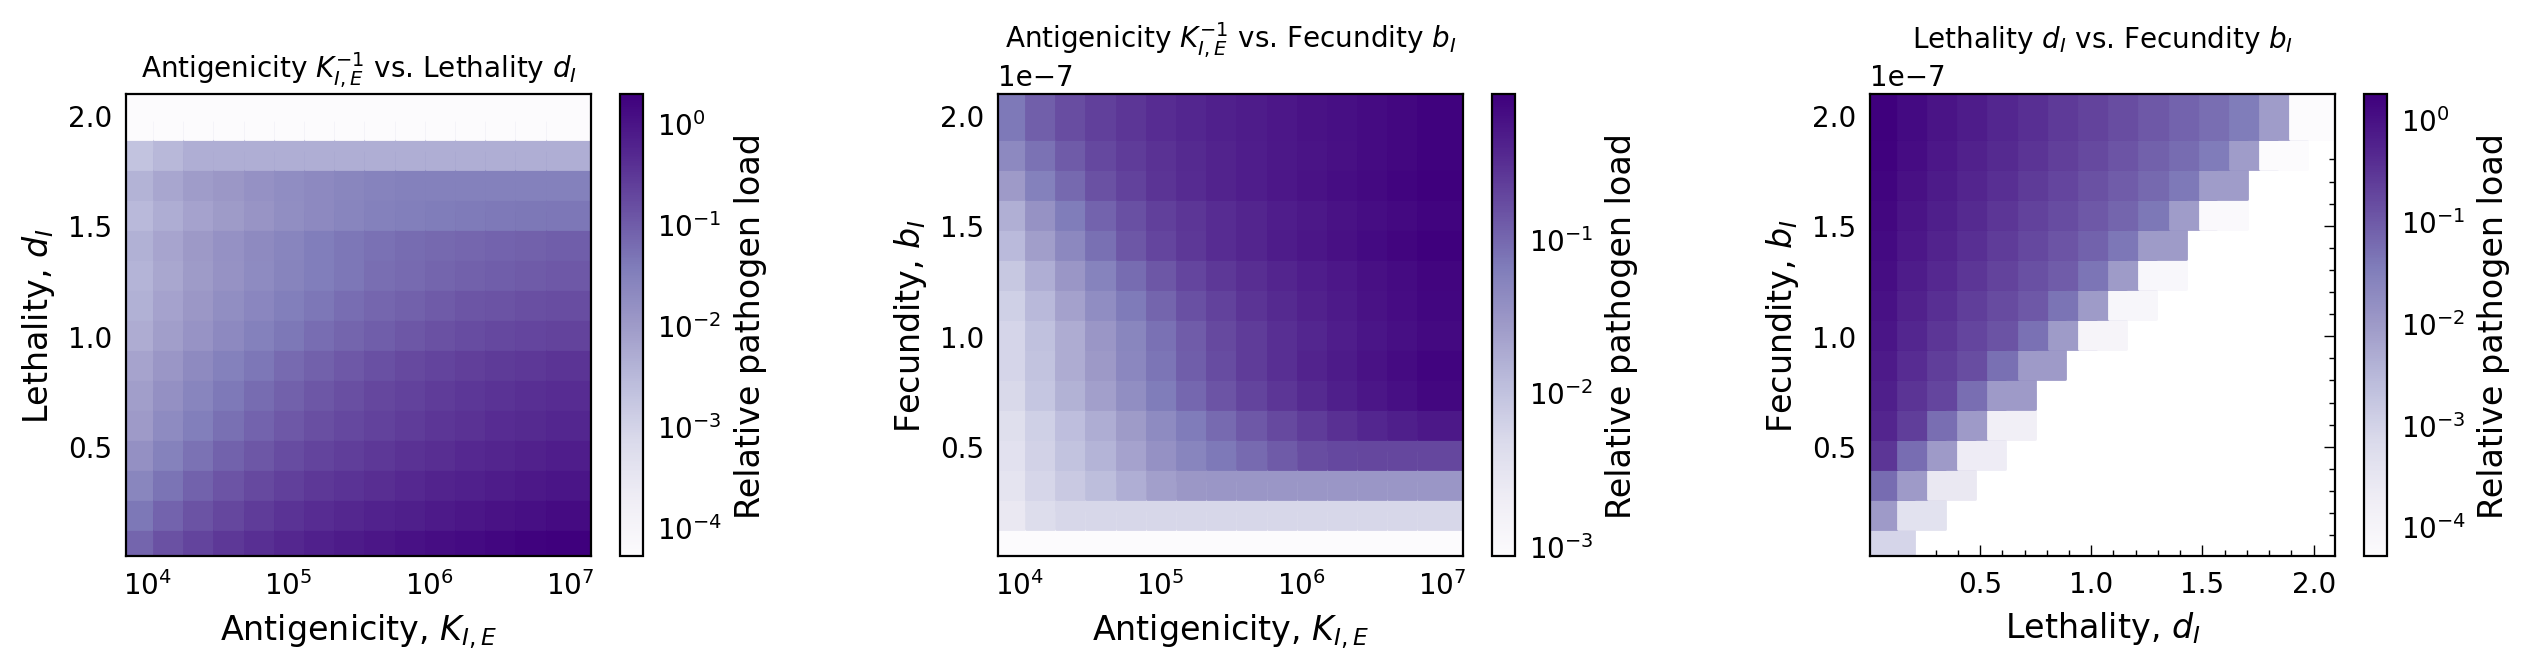

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}^{-1}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}^{-1}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pharm_heatmaps', dpi=300, bbox_inches='tight')

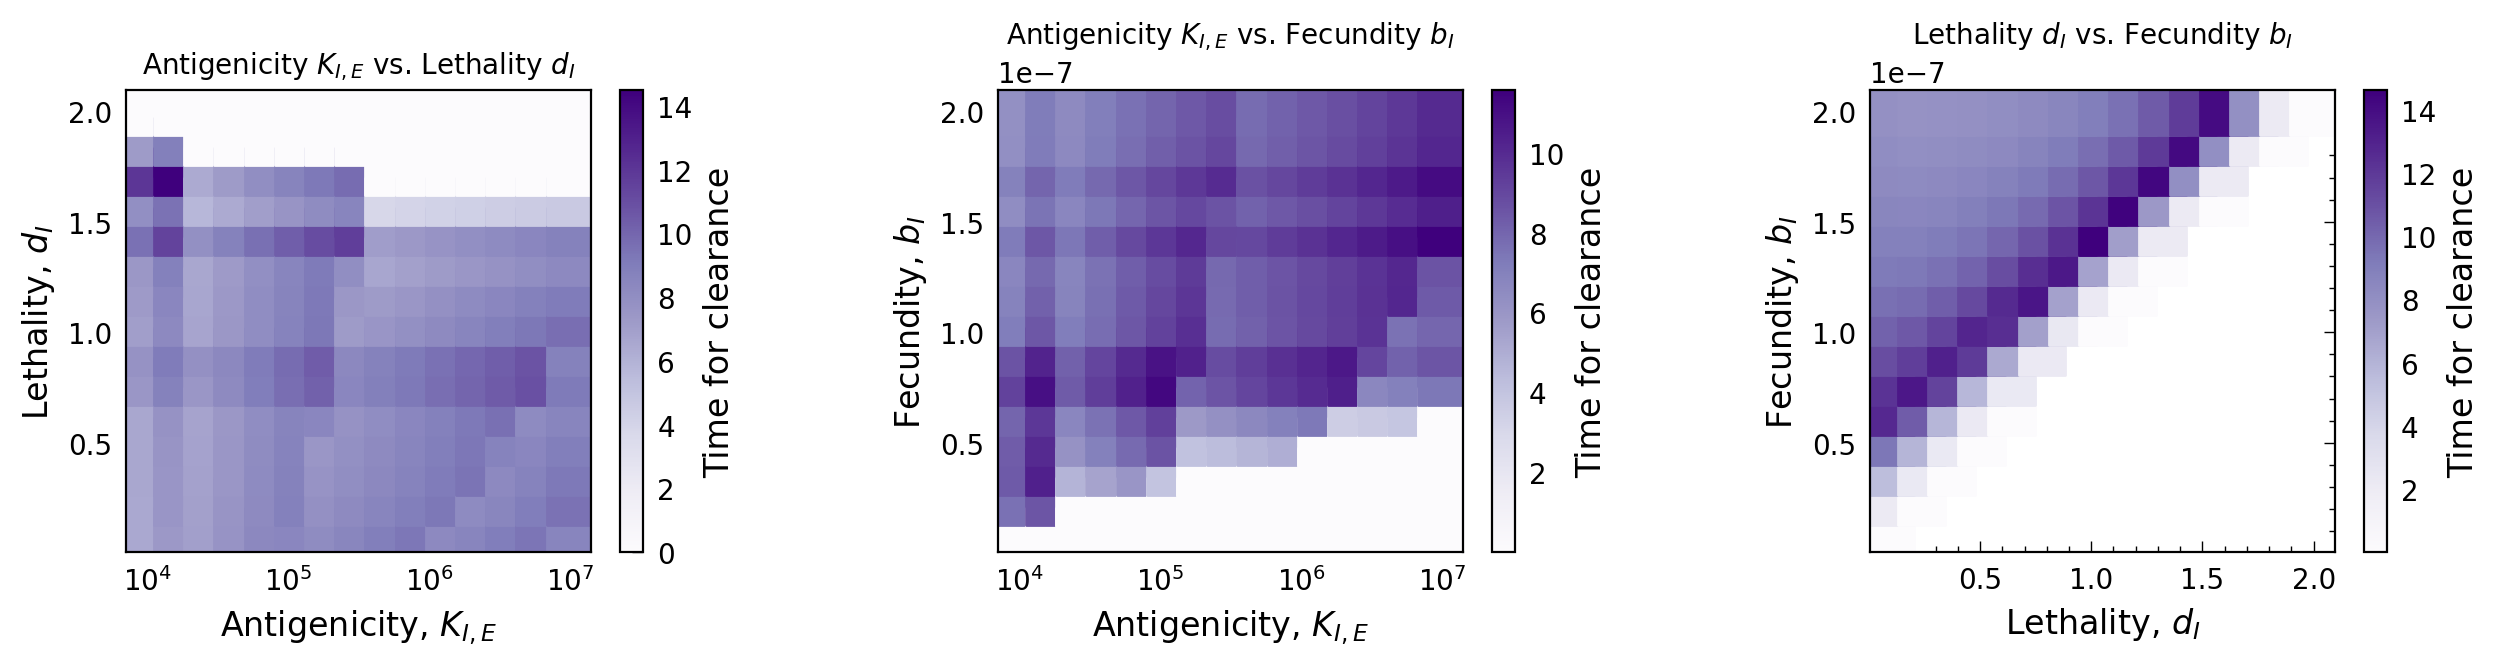

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_ptiming_heatmaps', dpi=300, bbox_inches='tight')

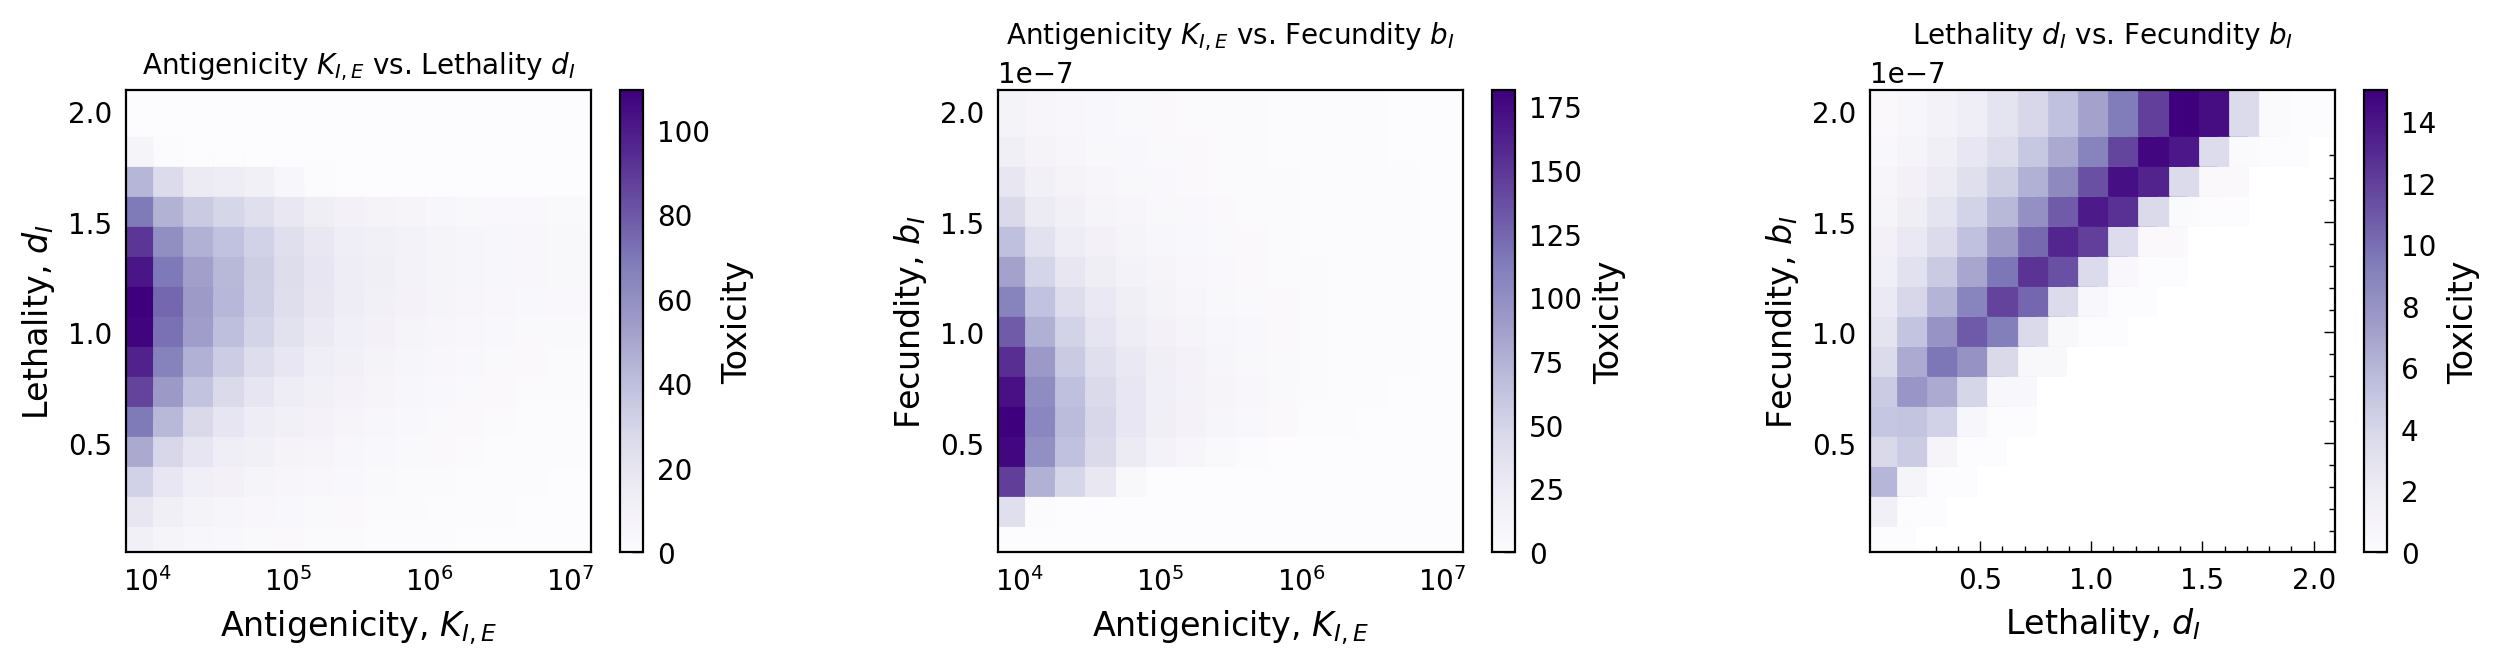

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_IE','d_I'], as_index=False).mean()['harm_pI'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_IE','b_I'], as_index=False).mean()['harm_pI'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pI'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_toxicity_heatmaps', dpi=300, bbox_inches='tight')

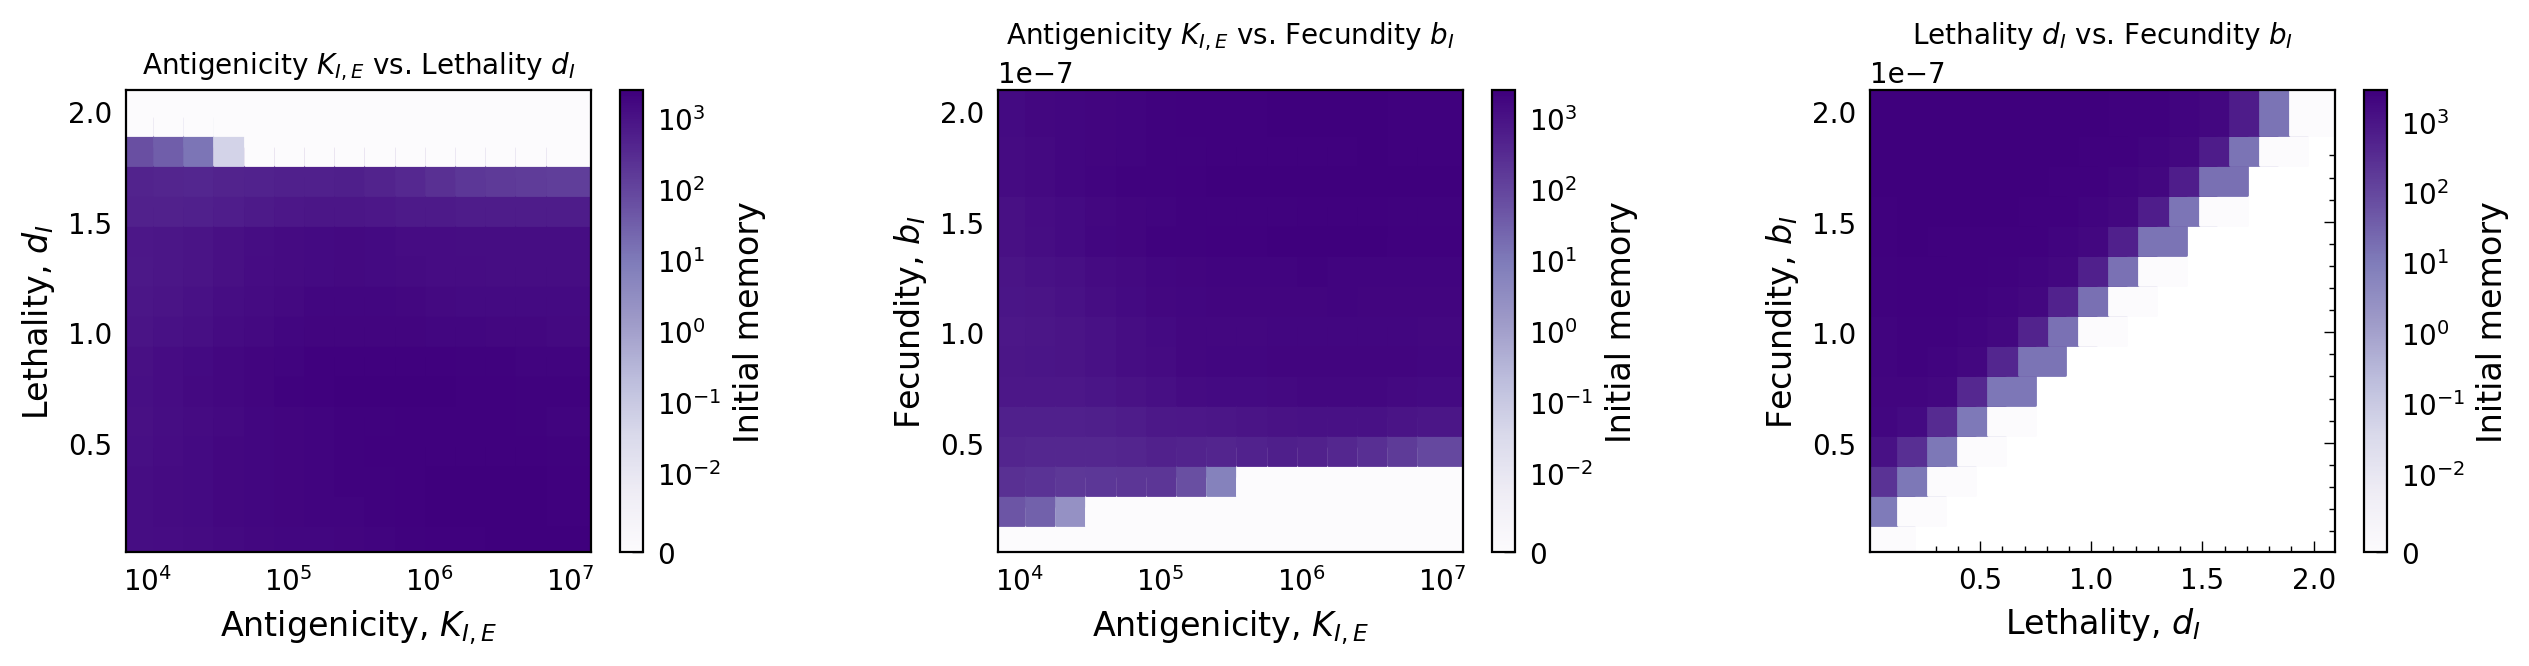

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_heatmaps', dpi=300, bbox_inches='tight')

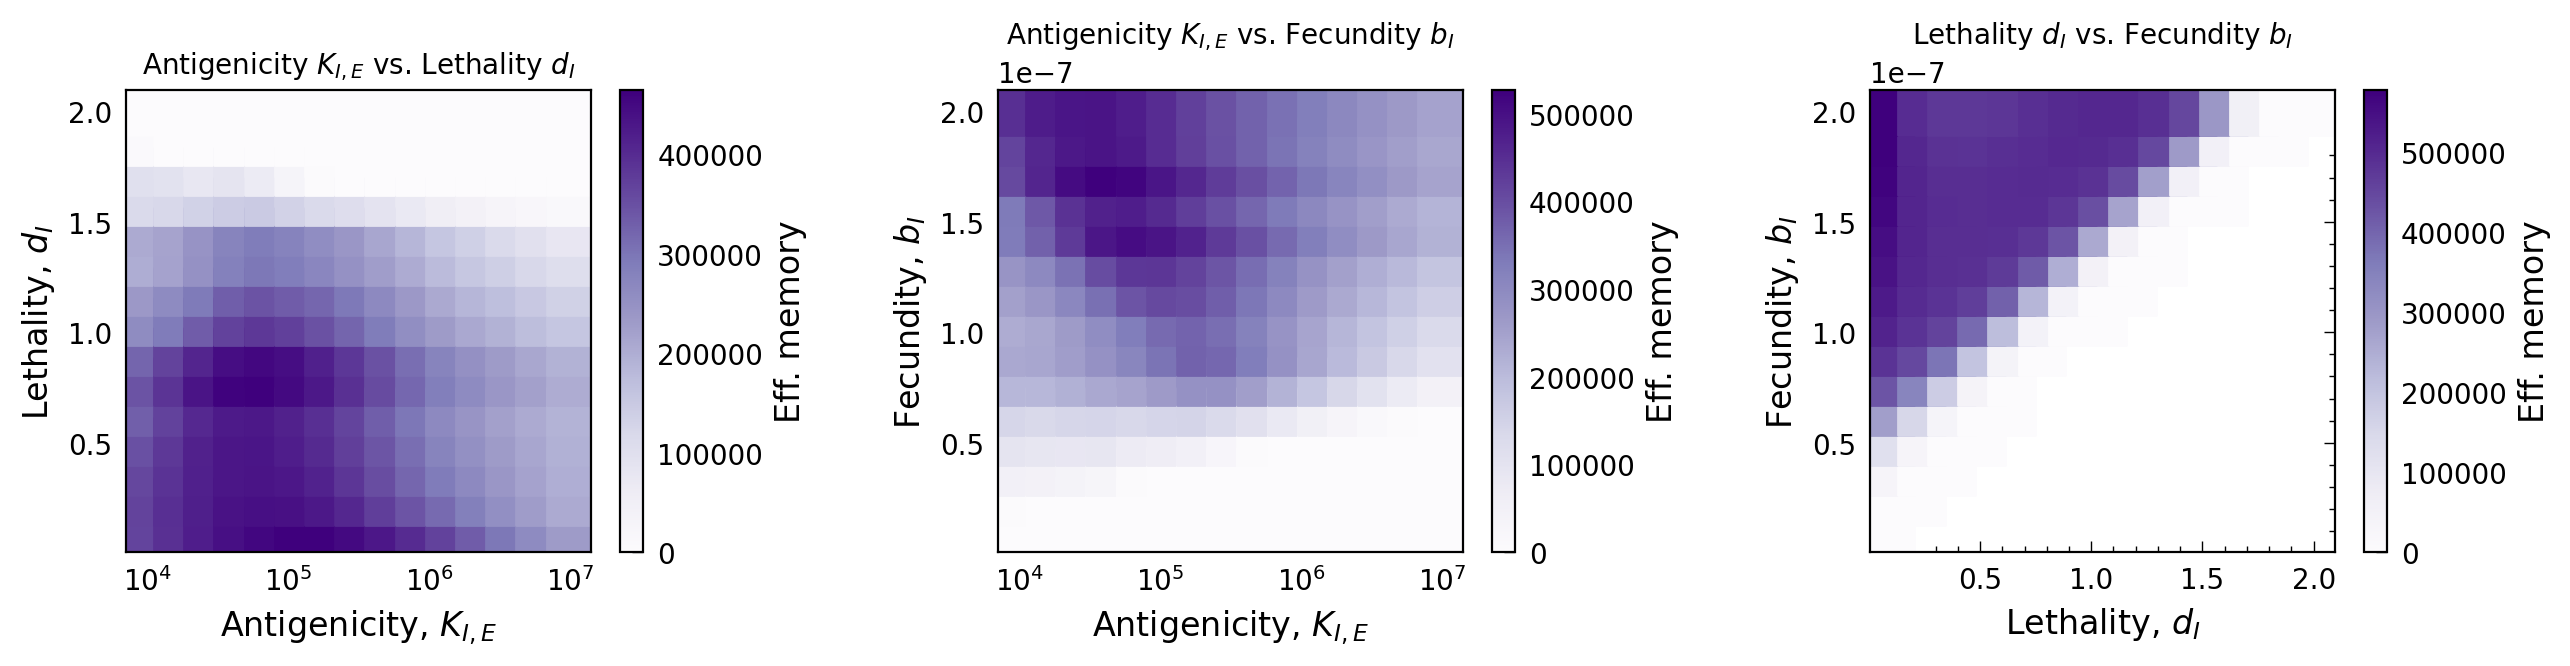

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_duration_heatmaps', dpi=300, bbox_inches='tight')